# Tuần 8 — Full Experiment Analysis (RQ1)

**RQ1:** Trên Defects4J Java projects (Commons Lang, Commons Math), GPT4o-mini-based
mutant selection (top 10% mutant pool, `gpt-4o-mini`, temperature=0, fixed ranking prompt)
có đạt mutation score cao hơn random fixed-seed selection (seed=42) cùng budget không?

- **H0:** MS_GPT4o <= MS_random
- **H1:** MS_GPT4o > MS_random
- **Metric:** Mutation Score = Killed / Selected, đo bằng PIT.
- **Test:** Wilcoxon signed-rank, một phía (`alternative="greater"`), α = 0.05.
- **Effect size:** matched-pairs rank-biserial correlation r_rb (ngưỡng thực tế r_rb ≥ 0.30, Jimenez et al. 2018).
- **Đơn vị bắt cặp (paired unit):** một unit = một nhóm (project, version, class_name); mỗi unit có
  MS_GPT4o và MS_random tính trên cùng số lượng mutant đã chọn (by-group top-10%, xem `notes.md` mục "Bug đã sửa").
- **Sub-group (pre-registered, proposal §6.3):** Commons Lang vs Commons Math, chỉ chạy test riêng nếu
  n_group ≥ 10, ngược lại chỉ báo cáo descriptive.

⚠️ Xem `notes.md` — kết quả subgroup Math có threat to validity đã biết (PIT chỉ chạy ở scope hẹp,
~1 class/version, so với Lang ~147 class/version), nên so sánh Lang vs Math (RQ3-style generalization)
CHƯA nên dùng để kết luận cho tới khi Math được chạy lại ở scope rộng tương đương.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "results" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from compute_metric import (
    to_bool_killed,
    load_selected_with_killed,
    build_paired_table,
    analyze_subset,
    GROUP_COLS,
    N_GROUP_MIN,
)

pd.set_option("display.width", 140)
ROOT


WindowsPath('D:/K5-2026/SWT301/Presentation/RT-SWT-003-nhom3-Tuan8')

## 1. Load data and merge ground truth

In [2]:
ground_truth = pd.read_csv(ROOT / "data" / "full_ground_truth.csv")
ground_truth["mutant_id"] = ground_truth["mutant_id"].astype(str)
ground_truth["killed"] = to_bool_killed(ground_truth["killed"])

gpt = load_selected_with_killed(ROOT / "results" / "full_gpt_selected.csv", ground_truth)
random_ = load_selected_with_killed(ROOT / "results" / "full_random_selected.csv", ground_truth)
gpt["killed"] = to_bool_killed(gpt["killed"])
random_["killed"] = to_bool_killed(random_["killed"])

print(f"GPT-selected mutants: {len(gpt)}  (Lang={ (gpt['project']=='Lang').sum() }, Math={ (gpt['project']=='Math').sum() })")
print(f"Random-selected mutants: {len(random_)}  (Lang={ (random_['project']=='Lang').sum() }, Math={ (random_['project']=='Math').sum() })")


GPT-selected mutants: 5438  (Lang=5135, Math=303)
Random-selected mutants: 5438  (Lang=5135, Math=303)


## 2. Mutation score per (project, version, class_name) group, paired

In [3]:
paired_all = build_paired_table(gpt, random_)
print(f"Total paired groups: {len(paired_all)}")
paired_all.groupby("project").size().rename("n_group")


Total paired groups: 757


project
Lang    739
Math     18
Name: n_group, dtype: int64

## 3. Wilcoxon signed-rank test (one-sided) + rank-biserial effect size

In [4]:
rows = [analyze_subset(paired_all, "RQ1_pooled_all_projects")]
for project in sorted(paired_all["project"].unique()):
    rows.append(analyze_subset(paired_all[paired_all["project"] == project], f"RQ1_subgroup_{project}"))

summary = pd.DataFrame(rows)
ordered_cols = [
    "subset", "n_group", "n_pairs", "n_nonzero_pairs",
    "mean_ms_gpt", "mean_ms_random", "median_ms_gpt", "median_ms_random",
    "win_gpt", "win_random", "tie",
    "p_value", "effect_size_rank_biserial", "ran_test", "reason_skipped",
]
for c in ordered_cols:
    if c not in summary.columns:
        summary[c] = np.nan
summary = summary[ordered_cols]
summary.to_csv(ROOT / "results" / "summary.csv", index=False, encoding="utf-8")
summary


,subset,n_group,n_pairs,n_nonzero_pairs,mean_ms_gpt,mean_ms_random,median_ms_gpt,median_ms_random,win_gpt,win_random,tie,p_value,effect_size_rank_biserial,ran_test,reason_skipped
0,RQ1_pooled_all_projects,757,757,256,0.834268,0.779154,1.000000,1.000000,180,76,501,1.734309e-09,0.425492,True,NaN
1,RQ1_subgroup_Lang,739,739,245,0.834279,0.777896,1.000000,1.000000,173,72,494,1.633260e-09,0.435606,True,NaN
2,RQ1_subgroup_Math,18,18,11,0.833804,0.830807,0.904167,0.861905,7,4,7,3.444690e-01,0.136364,True,NaN


## 4. Interpretation per subset (proposal §6.2 cases)

- **Pooled (757 units):** `p ≈ 1.73e-09 < 0.05` và `r_rb ≈ 0.425 ≥ 0.30` → điều kiện Case 1 (Significant
  positive) được thỏa. Tuy nhiên Lang chiếm 739/757 = 97.6% số unit pooled, nên số liệu pooled gần như
  phản ánh riêng Lang, KHÔNG nên diễn giải là "cả hai project".
- **Lang (739 units):** `p ≈ 1.63e-09 < 0.05` và `r_rb ≈ 0.436 ≥ 0.30` → ủng hộ H1 rõ ràng, độc lập với Math.
- **Math (18 units, 11 cặp non-zero):** `p ≈ 0.344 ≥ 0.05`, `r_rb ≈ 0.136 < 0.30` → Case 3 (Positive trend,
  không có ý nghĩa thống kê). mean MS_GPT4o (0.834) nhỉnh hơn mean MS_random (0.831), win_gpt=7 > win_random=4,
  nhưng chưa đủ ý nghĩa thống kê lẫn effect size. Không kết luận H1 cho Math riêng lẻ. Theo notes.md, n_group
  nhỏ (18) một phần do PIT chỉ chạy Math ở scope hẹp (~1 class/version) nên kém đại diện.

**Kết luận RQ1 (theo đúng success criteria §5.6/§6.1 của proposal):**
Ủng hộ H1 khi gộp tất cả project (`p < 0.05` và `r_rb ≥ 0.30`), chủ yếu do driven bởi Commons Lang. Trên
Commons Math riêng, có xu hướng tích cực (GPT4o-mini nhỉnh hơn random) nhưng chưa đủ ý nghĩa thống kê/effect
size để kết luận H1 (Case 3) — cần chạy lại Math ở scope PIT rộng hơn (xem amendment) trước khi kết luận về
generalization giữa hai project.

**Lưu ý reproducibility:** con số Math ở trên (Case 3) thay thế một phiên bản trước đó (Case 4, p=0.5,
r_rb=0.00) bị sinh ra bởi một bug trong `random_baseline.py` — `hash()` built-in của Python bị salt ngẫu
nhiên theo process nên random baseline theo group KHÔNG reproducible giữa các lần chạy dù `seed=42` cố định.
Đã sửa bằng `hashlib.sha256` (xem `notes.md` mục Bug 3); số liệu trong notebook này đã được xác nhận
reproducible qua 3 lần chạy độc lập cho cùng 1 md5 hash.


## 5. Figure 1 — Distribution of mutation score per group (GPT vs Random)

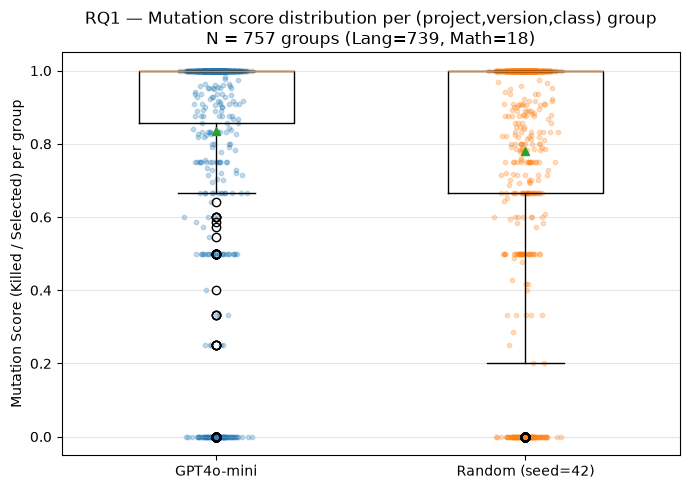

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
data = [paired_all["ms_gpt"], paired_all["ms_random"]]
bp = ax.boxplot(data, tick_labels=["GPT4o-mini", "Random (seed=42)"], showmeans=True, widths=0.5)
for i, d in enumerate(data, start=1):
    jitter = np.random.default_rng(42).normal(0, 0.04, size=len(d))
    ax.scatter(np.full(len(d), i) + jitter, d, alpha=0.25, s=10, color="tab:blue" if i == 1 else "tab:orange")

ax.set_ylabel("Mutation Score (Killed / Selected) per group")
ax.set_title(f"RQ1 — Mutation score distribution per (project,version,class) group\nN = {len(paired_all)} groups (Lang={ (paired_all['project']=='Lang').sum() }, Math={ (paired_all['project']=='Math').sum() })")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(ROOT / "figures" / "fig1_distribution.png", dpi=300)
plt.show()


## 6. Figure 2 — Comparison of mean mutation score by project

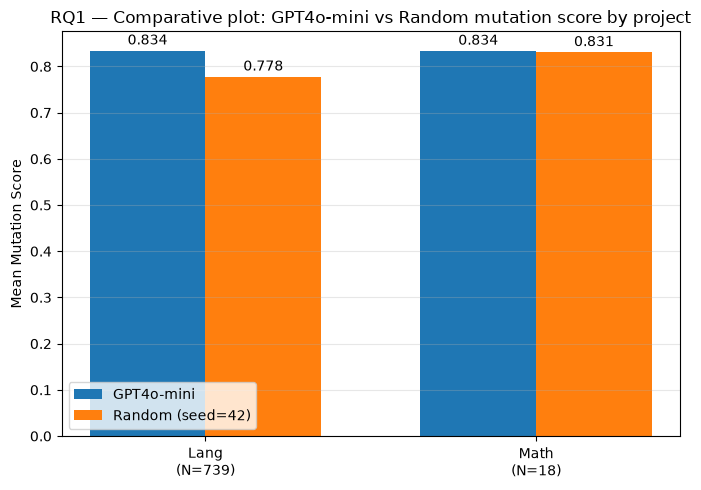

In [6]:
summary_by_project = paired_all.groupby("project").agg(
    n_group=("mutant_id" if "mutant_id" in paired_all.columns else "ms_gpt", "size"),
    mean_ms_gpt=("ms_gpt", "mean"),
    mean_ms_random=("ms_random", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(summary_by_project))
width = 0.35
b1 = ax.bar(x - width/2, summary_by_project["mean_ms_gpt"], width, label="GPT4o-mini")
b2 = ax.bar(x + width/2, summary_by_project["mean_ms_random"], width, label="Random (seed=42)")
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n(N={n})" for p, n in zip(summary_by_project["project"], summary_by_project["n_group"])])
ax.set_ylabel("Mean Mutation Score")
ax.set_title("RQ1 — Comparative plot: GPT4o-mini vs Random mutation score by project")
ax.bar_label(b1, fmt="%.3f", padding=2)
ax.bar_label(b2, fmt="%.3f", padding=2)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(ROOT / "figures" / "fig2_comparison.png", dpi=300)
plt.show()


## 6. Ghi chú

- `results/summary.csv`: metric/p-value/effect-size/N cho từng subset (pooled, Lang, Math).
- `results/paired_mutation_scores.csv`: bảng paired đầy đủ (757 dòng, 1 dòng/group) dùng cho các phân tích
  trên, có thể mở lại để kiểm tra thủ công.
- Xem `notes.md` cho toàn bộ quyết định kỹ thuật, 2 bug đã sửa (global tie-break, group-by version thay vì
  class), và threat to validity còn tồn đọng (Math PIT scope hẹp) đang chờ amendment.
